<a href="https://colab.research.google.com/github/AllenGeorge08/NeuralNetworksFromScratch/blob/master/MakemoreBatchnormFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-10-02 16:46:20--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.09s   

2026-10-02 16:46:20 (2.48 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open('names.txt','r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [ ]:
block_size=3

def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0]*block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X  = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr  = build_dataset(words[:n1])
Xdev,Ydev  = build_dataset(words[n1:n2])
Xte,Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
g = torch.Generator().manual_seed(2147483647)

In [ ]:
# MLP
n_embd = 10 #dim of the char embedding vectros
n_hidden = 200
C = torch.randn((vocab_size,n_embd),generator=g) #Char embedding table , 27*10, 10 numbers for each character
W1 = torch.randn((n_embd*block_size,n_hidden),generator=g)*(5/3)/((n_embd*block_size)**0.5) #scale by fan_in and multiply by tanh gain 5/3

W2 = torch.randn((n_hidden,vocab_size),generator=g)*0.01
b2 = torch.randn(vocab_size,generator=g)*0

# Batchnorm parameters
# C[Xtr].shape  # if it'ss torch.Size([182625, 3, 10]) then we flatten it to torch.Size([182625, 30])

# Gamma and beta = 1,0
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,W1,W2,b2,bngain,bnbias]

for p in parameters:
  p.requires_grad = True

In [ ]:
# Forward pass
def forward(Xb):
  emb = C[Xb] #(B,3,10)
  embcat = emb.view(emb.shape[0],-1) #(B,30)

  hpreact = embcat@W1  #(B,100) W1 = (30,200)
  bnmean = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0,keepdim=True)

  hpreact = bngain*(hpreact-bnmean)/bnstdi+bnbias
  h = torch.tanh(hpreact)
  logits = h@W2+b2
  return logits

In [ ]:
# Training
max_steps = 20000
batch_size = 32
lossi = []

# Wnew = Wold - lr*p.grad
for step in range(max_steps):
  ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)

  Xb = Xtr[ix]
  Yb = Ytr[ix]

  logits = forward(Xb)
  loss = F.cross_entropy(logits,Yb)
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if step < 10000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  if step%100 == 0:
    lossi.append(loss.log10().item())

print(loss.item())

2.30033278465271


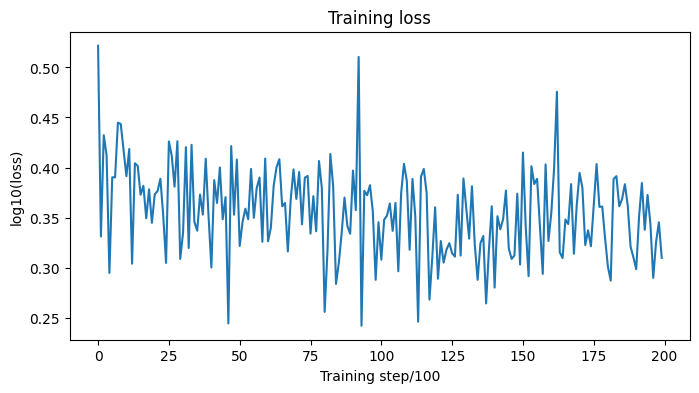

In [ ]:
# Plotting the loss
plt.figure(figsize=(8,4))
plt.plot(lossi)
plt.xlabel("Training step/100")
plt.ylabel("log10(loss)")
plt.title("Training loss")
plt.show()

In [ ]:
@torch.no_grad
def split_loss(split):
  X,Y = {
      "train": (Xtr,Ytr),
      "val": (Xdev,Ydev),
      "test": (Xte,Yte)
  }[split]

  logits = forward(X)
  loss = F.cross_entropy(logits,Y)

  print(split,loss.item())


split_loss("train")
split_loss("val")
split_loss("test")

train 2.1880476474761963
val 2.195751667022705
test 2.2006165981292725


In [ ]:
# MLP
# Linear Layer
class Linear:
  def __init__(self,fan_in,fan_out,bias=True):
    self.weight=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self,x):
    self.out = x@self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


In [ ]:
class BatchNorm1d:
  def __init__(self,dim,eps=1e-5,momentum=0.1):
    self.eps = eps
    self.momentum = momentum

    self.training = True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)


  def __call__(self,x):
    if self.training:
      xmean = x.mean(0,keepdim=True)
      xvar = x.var(0,keepdim=True)

      with torch.no_grad():
        self.running_mean = ((1-self.momentum)*self.running_mean +self.momentum*xmean)
        self.running_var = ((1-self.momentum)*self.running_var + self.momentum*xvar)

    else:
      xmean = self.running_mean
      xvar = self.running_var

    xhat = (x-xmean)/torch.sqrt(xvar+self.eps)

    self.out = self.gamma*xhat + self.beta

    return self.out


  def parameters(self):
    return [self.gamma,self.beta]


In [ ]:
class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    if self.out.requires_grad:
      self.out.retain_grad() #retain output of intermediate tensor
    return self.out


  def parameters(self):
    return []

In [ ]:
layers = [
    Linear(30,100,bias=False),
    BatchNorm1d(100),
    Tanh(),

    Linear(100,100,bias=False),
    BatchNorm1d(100),
    Tanh(),

    Linear(100,100,bias=False),
    BatchNorm1d(100),
    Tanh(),

    Linear(100,100,bias=False),
    BatchNorm1d(100),
    Tanh(),

    Linear(100,27,bias=False),
    BatchNorm1d(27)
]

In [ ]:
parameters=[]
for layer in layers:
  parameters.extend(layer.parameters())

for p in parameters:
  p.requires_grad = True

print("Total Parameters: ",sum(p.nelement() for p in parameters))

Total Parameters:  36554


In [ ]:
max_steps = 20000
batch_size = 32
lossi = []

for step in range(max_steps):
  ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g) #low 0  to high(total numbers of rows in your training dataset)

  Xb = Xtr[ix]
  Yb = Ytr[ix]

  #Forward
  x = C[Xb]
  x = x.view(x.shape[0],-1)

  for layer in layers:
    x = layer(x)


  loss = F.cross_entropy(x,Yb)
  for p in parameters:
    p.grad = None

  loss.backward()


  # Update
  lr = 0.1 if step<15000 else 0.01


  for p in parameters:
    p.data += -lr*p.grad

  if step%100==0:
    lossi.append(loss.log10().item())



Text(0, 0.5, 'Count')

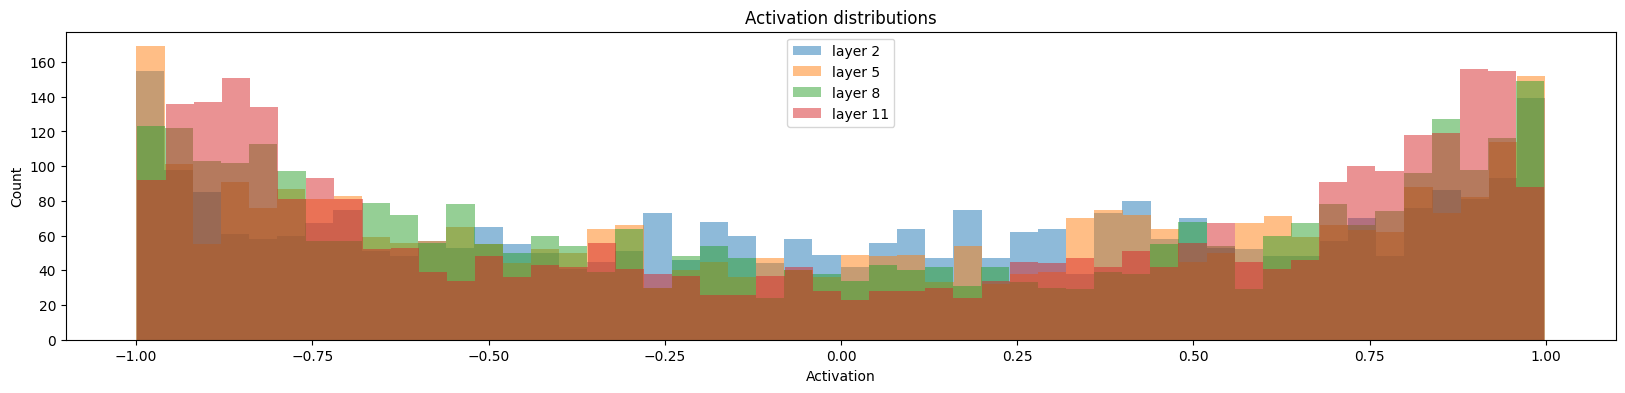

In [ ]:
plt.figure(figsize=(20,4))
legends=[]

for i,layer in enumerate(layers):
  if isinstance(layer,Tanh):
    t = layer.out

    plt.hist(t.detach().view(-1).numpy(), bins=50,alpha=0.5)
    legends.append(f'layer {i}')


plt.legend(legends)
plt.title("Activation distributions")
plt.xlabel("Activation")
plt.ylabel("Count")


In [ ]:
# Qunatify the activations
for i ,layer in enumerate(layers):
  if isinstance(layer,Tanh):
    t = layer.out
    print(f"layer {i}:" f"mean {t.mean():+.2f}," f"std {t.std():.2f}" f", saturated {(t.abs()>0.97).float().mean()*100:.2f}%")

layer 2:mean +0.00,std 0.63, saturated 7.28%
layer 5:mean -0.00,std 0.66, saturated 7.62%
layer 8:mean -0.01,std 0.68, saturated 6.00%
layer 11:mean +0.01,std 0.70, saturated 3.72%


In [ ]:
# Before training, we want the intermediate activatiosns to retain their gradientss
for i,layer in enumerate(layers):
  if isinstance(layer,Tanh):
    print(i,layer.out.grad is None)



2 False
5 False
8 False
11 False


Text(0, 0.5, 'Count')

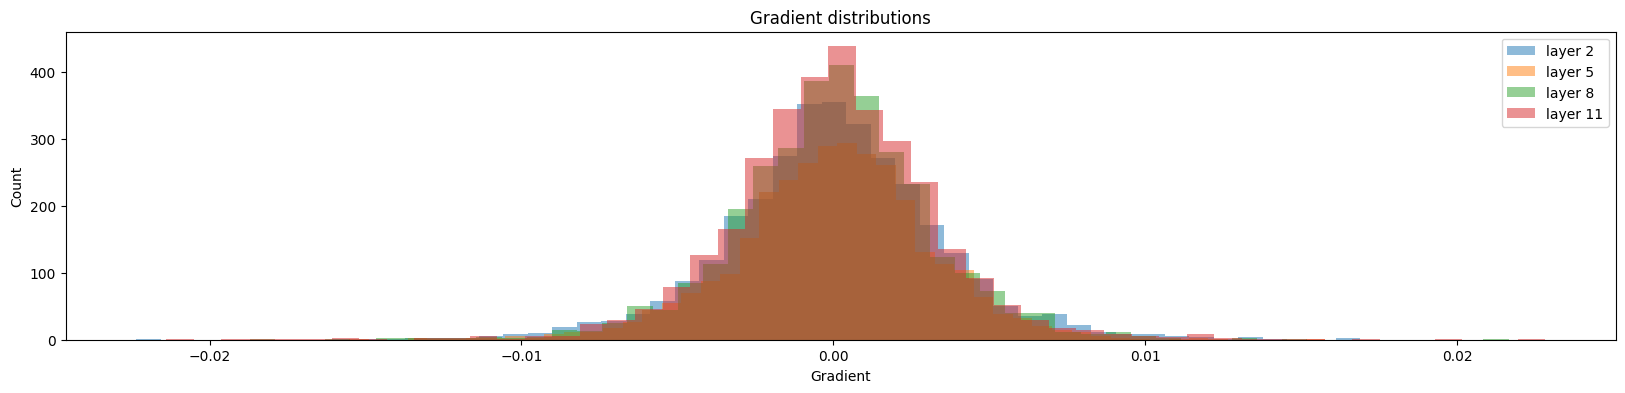

In [ ]:
plt.figure(figsize=(20,4))
legends = []

for i,layer in enumerate(layers):
  if isinstance(layer,Tanh):
    t = layer.out.grad
    plt.hist(t.detach().view(-1).numpy(),bins=50,alpha=0.5),

    legends.append(f"layer {i}")


plt.legend(legends)
plt.title("Gradient distributions")
plt.xlabel("Gradient")
plt.ylabel("Count")


In [ ]:
for i,layer in enumerate(layers):
  if isinstance(layer,Tanh):
    t = layer.out.grad
    print(f"Layer {i}:" f"Mean {t.mean():+.2e}" f"std {t.std():.2e}")

Layer 2:Mean +0.00e+00std 3.52e-03
Layer 5:Mean +8.73e-12std 3.09e-03
Layer 8:Mean +9.31e-12std 3.16e-03
Layer 11:Mean -3.49e-12std 3.32e-03


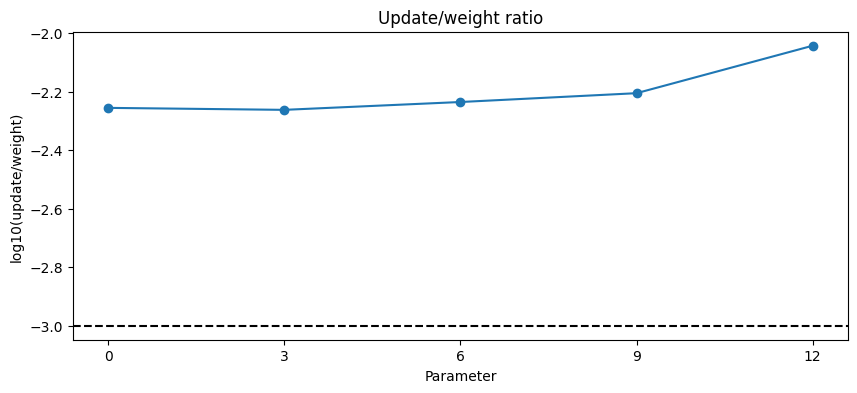

In [ ]:
ratios = []
names = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        ratio = (0.1 * p.grad.std() / p.data.std()).log10().item()
        ratios.append(ratio)
        names.append(i)

plt.figure(figsize=(10, 4))
plt.plot(range(len(ratios)), ratios, 'o-')
plt.axhline(-3, linestyle="--", color='k')
plt.xticks(range(len(ratios)), names)
plt.title("Update/weight ratio")
plt.ylabel("log10(update/weight)")
plt.xlabel("Parameter")
plt.show()

In [ ]:
# Train vs eval
for layer in layers:
  if isinstance(layer,BatchNorm1d):
    layer.training = False


with torch.no_grad():
  x = C[Xdev]
  x = x.view(x.shape[0],-1)

  for layer in layers:
    x = layer(x)

  val_loss = F.cross_entropy(x,Ydev)


print("Validation Loss: ",val_loss.item())


Validation Loss:  2.1523947715759277
